#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


In [4]:
import cv2

# Reading the image
img = cv2.imread("plaksha_Faculty.jpg")

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Applying the face detection method on the grayscale image
faces_rect = face_cascade.detectMultiScale(
    gray_img,
    scaleFactor=1.05,
    minNeighbors=4,
    minSize=(25, 25),
    maxSize=(50, 50)
)

# Define the text and font parameters
text = "Face"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
font_color = (0, 0, 255)   # Red in BGR format
font_thickness = 1

# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.putText(
        img,
        text,
        (x, y - 5),
        font,
        font_scale,
        font_color,
        font_thickness
    )

# Display the image
window_title = f"Total number of face detected are {len(faces_rect)}"
cv2.imshow(window_title, img)

cv2.waitKey(0)
cv2.destroyAllWindows()


c:\Users\kuhuk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


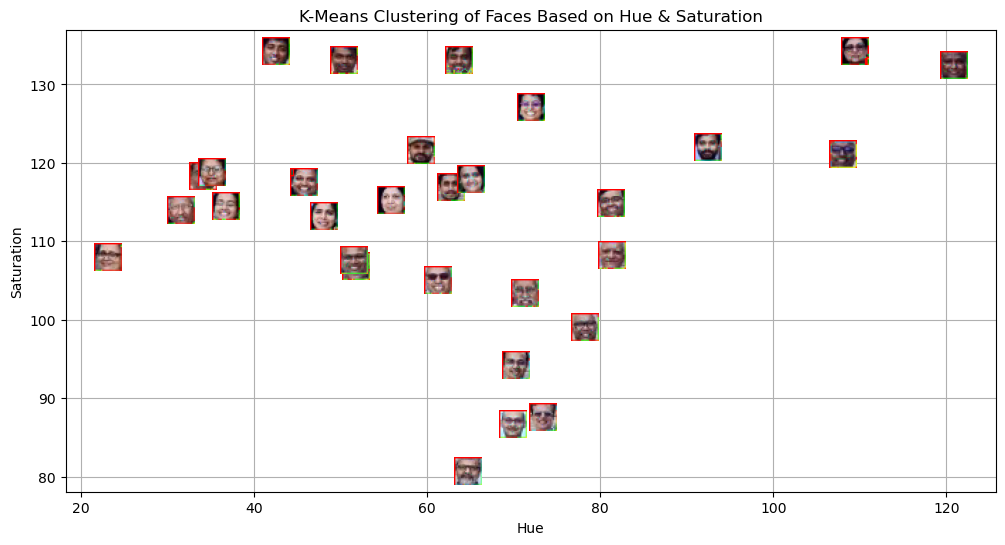

In [5]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

# Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=3, random_state=42).fit(hue_saturation)
# centroids = kmeans.cluster_centers_
# labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x, y, w, h) in enumerate(faces_rect):
    im = OffsetImage(
        cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB)
    )
    ab = AnnotationBbox(
        im,
        (hue_saturation[i, 0], hue_saturation[i, 1]),
        frameon=False,
        pad=0
    )
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])

# Put labels and title
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("K-Means Clustering of Faces Based on Hue & Saturation")
plt.grid(True)

# Show the plot
plt.show()


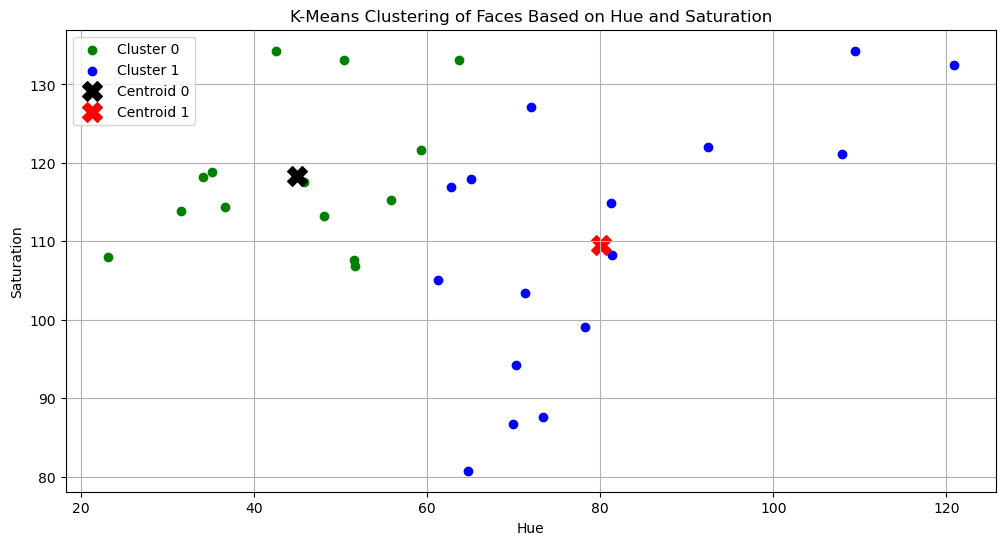

In [6]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Convert to numpy arrays
cluster_0_points = np.array(cluster_0_points)
cluster_1_points = np.array(cluster_1_points)

# Plot points for cluster 0 in green
plt.scatter(
    cluster_0_points[:, 0],
    cluster_0_points[:, 1],
    color='green',
    label='Cluster 0'
)

# Plot points for cluster 1 in blue
plt.scatter(
    cluster_1_points[:, 0],
    cluster_1_points[:, 1],
    color='blue',
    label='Cluster 1'
)

# Calculate centroids
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)

# Plot centroids
plt.scatter(
    centroid_0[0],
    centroid_0[1],
    color='black',
    marker='X',
    s=200,
    label='Centroid 0'
)

plt.scatter(
    centroid_1[0],
    centroid_1[1],
    color='red',
    marker='X',
    s=200,
    label='Centroid 1'
)

# Labels, title, legend, grid
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("K-Means Clustering of Faces Based on Hue and Saturation")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


In [7]:
# Read the template image
template_img = cv2.imread("Dr_Shashi_Tharoor.jpg")

# Convert to grayscale
template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)

# Detect faces in the template image
template_faces = face_cascade.detectMultiScale(
    template_gray,
    scaleFactor=1.05,
    minNeighbors=4,
    minSize=(25, 25)
)

# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)

# Display the image
cv2.imshow("Detected Face in Template Image", template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


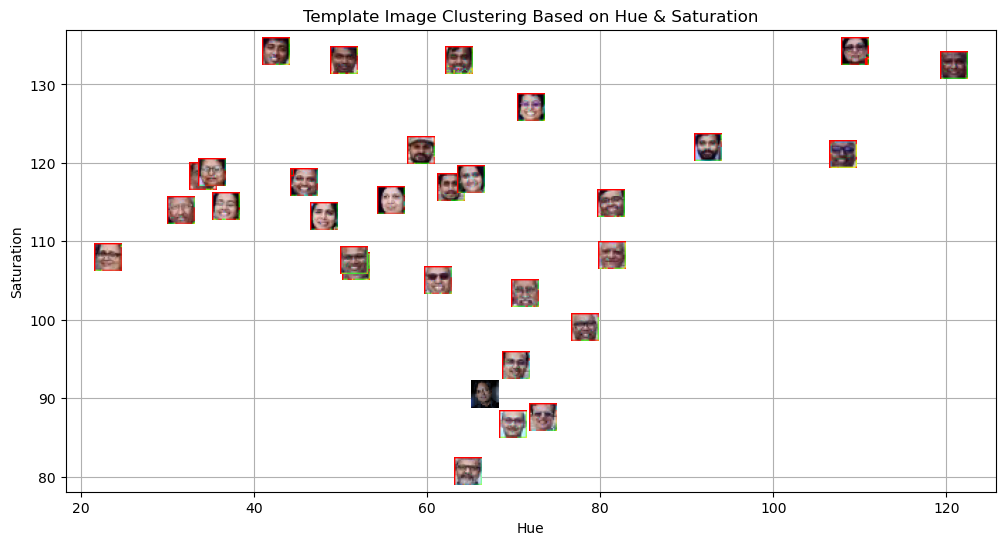

In [8]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img, cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image
template_hue = np.mean(template_hsv[:, :, 0])
template_saturation = np.mean(template_hsv[:, :, 1])

# Predict the cluster label for the template image
template_label = kmeans.predict([[template_hue, template_saturation]])[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(
        cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB)
    )
    ab = AnnotationBbox(
        im,
        (hue_saturation[i, 0], hue_saturation[i, 1]),
        frameon=False,
        pad=0
    )
    ax.add_artist(ab)
    plt.plot(
        hue_saturation[i, 0],
        hue_saturation[i, 1],
        'o',
        markersize=5,
        color=color
    )

# Plot the template image in the respective cluster
color = 'red' if template_label == 0 else 'blue'
im = OffsetImage(
    cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB)
)
ab = AnnotationBbox(
    im,
    (template_hue, template_saturation),
    frameon=False,
    pad=0
)
ax.add_artist(ab)

# Labels, title, grid
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Template Image Clustering Based on Hue & Saturation")
plt.grid(True)

# Show plot
plt.show()


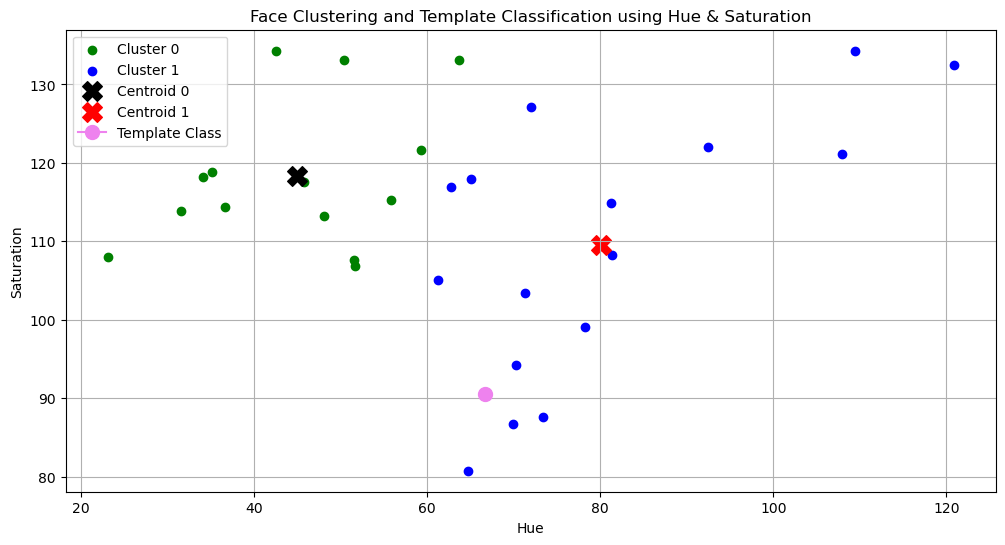

In [9]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(
    cluster_0_points[:, 0],
    cluster_0_points[:, 1],
    c='green',
    label='Cluster 0'
)

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(
    cluster_1_points[:, 0],
    cluster_1_points[:, 1],
    c='blue',
    label='Cluster 1'
)

# Calculate centroids
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)

# Plot centroids
plt.scatter(
    centroid_0[0],
    centroid_0[1],
    marker='X',
    c='black',
    s=200,
    label='Centroid 0'
)

plt.scatter(
    centroid_1[0],
    centroid_1[1],
    marker='X',
    c='red',
    s=200,
    label='Centroid 1'
)

# Plot template image feature point
plt.plot(
    template_hue,
    template_saturation,
    marker='o',
    c='violet',
    markersize=10,
    label='Template Class'
)

# Labels, title, legend, grid
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Face Clustering and Template Classification using Hue & Saturation")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


## Report:
## Answer the following questions within your report:


## 1. What are the common distance metrics used in distance-based classification algorithms? 
### Ans: Common distance metrics in distance-based classification algorithms include Euclidean distance, Manhattan distance, Minkowski distance, and Cosine similarity. These metrics help determine the closeness of data points for classification. These metrics quantify similarity by measuring the distance between feature vectors. The smaller the distance, the more similar the data points are considered to be.

## 2. What are some real-world applications of distance-based classification algorithms? 
### Ans :  Real-world applications of distance-based classification algorithms include handwritten digit recognition (e.g., MNIST), medical diagnosis (disease prediction), recommendation systems, and fraud detection. One of the most well-known datasets is the MNIST handwritten digit dataset. Distance-based classifiers like KNN are often used to classify digits (0–9) based on pixel similarity.


## 3. Explain various distance metrics.
### Ans : Distance metrics: Euclidean Distance: Measures straight-line distance. Manhattan Distance: Measures distance along axes (grid-like). Minkowski Distance: Generalized form of Euclidean and Manhattan. Cosine Similarity: Measures angular similarity between vectors.

## 4. What is the role of cross validation in model performance? 
###  Ans : Cross-validation helps assess model performance by dividing data into training and validation sets multiple times, ensuring the model generalizes well and reducing overfitting or underfitting risks.



## 5. Explain variance and bias in terms of KNN? 
### Ans : In KNN, high bias (low K) leads to overfitting, capturing noise, while high variance (high K) results in underfitting, making the model less sensitive to data patterns. A balanced K value is crucial.